In [ ]:
import pandas as pd #PARA DATOS; estructura y manipulación
import numpy as np #PARA OPERACIONES; operaciones nméricas eficientes sobre arreglos
import matplotlib.pyplot as plt #para visualización (tablas)
import requests

In [17]:
df.head(3)

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260


In [18]:
df.shape

(19402, 4)

In [19]:
df.columns.tolist()

['entity', 'code', 'year', 'fertility_rate_hist']

In [20]:
df.dtypes

entity                     str
code                       str
year                     int64
fertility_rate_hist    float64
dtype: object

In [21]:
mexico = df[df['entity'] == 'Mexico']
japan = df[df['entity'] == 'Japan']

In [22]:
mexico.shape
japan.shape

(77, 4)

In [ ]:
#Arreglos numpy
year_mexico = mexico['year'].to_numpy()
rate_mexico = mexico['fertility_rate_hist'].to_numpy()

year_japan = japan['year'].to_numpy()
rate_japan = japan['fertility_rate_hist'].to_numpy()

In [24]:
promedio_mexico = np.mean(rate_mexico)

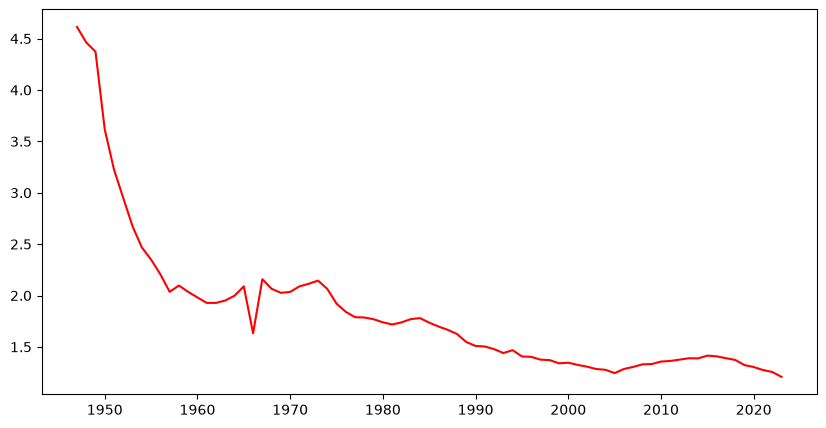

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(
    year_japan, rate_japan, label='Japan', color='red'
)


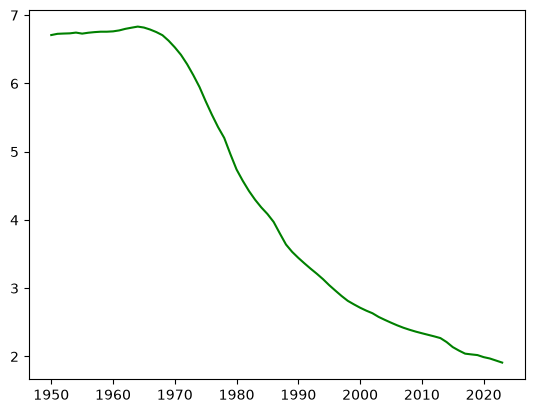

In [26]:
plt.plot(
    year_mexico, rate_mexico, label='Mexico', color='green'
)

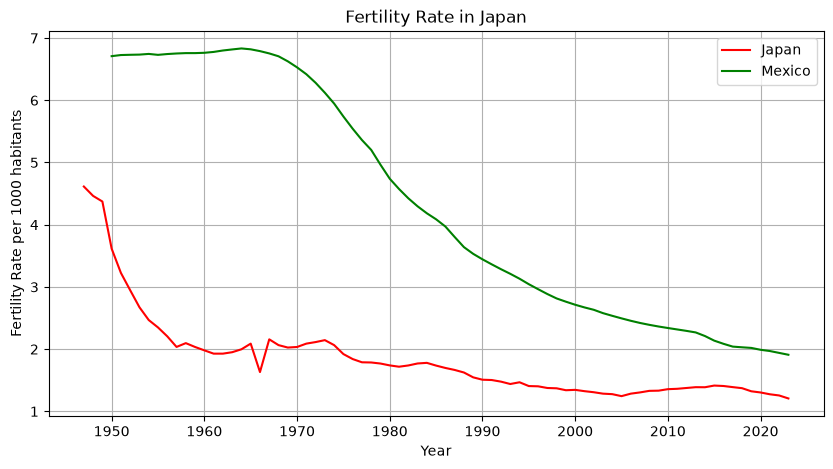

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(
    year_japan, rate_japan, label='Japan', color='red'
)

plt.plot(
    year_mexico, rate_mexico, label='Mexico', color='green'
)

plt.title('Fertility Rate in Japan')
plt.xlabel('Year')
plt.ylabel('Fertility Rate per 1000 habitants')
plt.grid()
plt.legend()

In [30]:
mexico.shape

(74, 4)

In [31]:
japan.shape

(77, 4)

In [33]:
mexico.head(1)

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709


In [34]:
japan.head(1)

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614


In [47]:
diferencia = rate_mexico -rate_japan

In [48]:
year_japan.shape

(74,)

In [49]:
year_mexico.shape

(74,)

In [60]:
mascara_coincidencia_anios = year_japan >= year_mexico.min()
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [61]:
year_japan2 = year_japan[mascara_coincidencia_anios]

In [63]:
rate_japan2 = rate_japan[mascara_coincidencia_anios]
rate_japan2.shape

(74,)

In [44]:
len(rate_japan)

74

In [64]:
diferencia_mx_jp = rate_mexico - rate_japan2



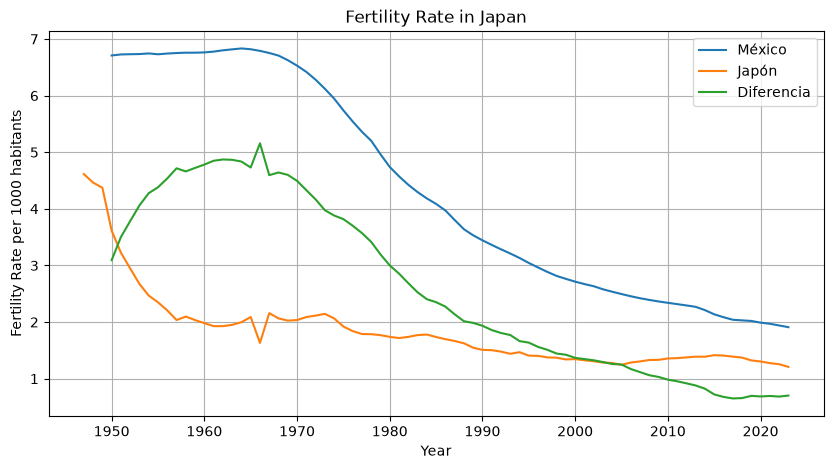

In [67]:
plt.figure(figsize = (10,5))

plt.plot(
    year_mexico,
    rate_mexico,
    label = "México"
)

plt.plot(
    year_japan,
    rate_japan,
    label = "Japón"
)

plt.plot(
    year_mexico,
    diferencia_mx_jp,
    label = "Diferencia"
)
plt.title('Fertility Rate in Japan')
plt.xlabel('Year')
plt.ylabel('Fertility Rate per 1000 habitants')
plt.grid()
plt.legend()

In [69]:
#hacemos un array con los años que tienen en comun cada dataset. 
common_years = np.intersect1d(
    year_mexico,
    year_japan
)

In [70]:
len(common_years)

74

In [71]:
type(common_years)

numpy.ndarray

In [78]:
mexico_common_years = mexico[mexico["year"].isin(common_years)]
japan_common_years = japan[japan["year"].isin(common_years)]

In [79]:
mexico_rate_commYears = mexico_common_years["fertility_rate_hist"].isin(common_years)
japan_rate_commYears = japan_common_years["fertility_rate_hist"].isin(common_years) 

In [80]:
mex_common_years = mexico_common_years["year"].to_numpy()
jap_common_years = japan_common_years["year"].to_numpy()

mex_rate_common_years = mexico_common_years["fertility_rate_hist"].to_numpy()
jap_rate_common_years = japan_common_years["fertility_rate_hist"].to_numpy()

In [81]:
print(year_japan[30])

1977


TypeError: unhashable type: 'numpy.ndarray'

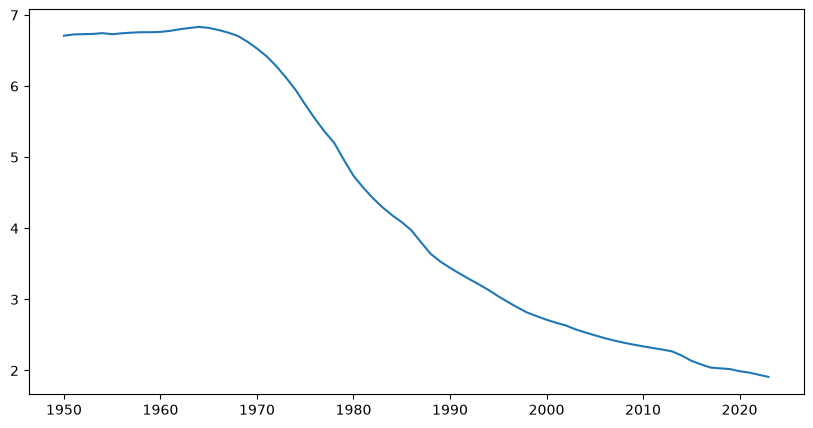

In [91]:
plt.figure(figsize = (10,5))

plt.plot(
    mex_common_years,
    mex_rate_common_years,
    label = "México"
)

plt.plot(
    japan_common_years,
    japan_rate_commYears,
    label = "Japón"
)

plt.title('Fertility Rate in Japan')
plt.xlabel('Year')
plt.ylabel('Fertility Rate per 1000 habitants')
plt.grid()
plt.legend()

In [82]:
##LA FORMA MÁS SENCILLA!!!
#UTILIZANDO MERGE

comparison_mex_jpn = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japan[["year", "fertility_rate_hist"]],
    on = "year",
    suffixes=("_mexico", "_japon")
)

In [83]:
comparison_mex_jpn.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947


In [84]:
comparison_mex_jpn["diferencia"] = (
    comparison_mex_jpn["fertility_rate_hist_mexico"]
    - comparison_mex_jpn["fertility_rate_hist_japon"] #esto es una operacion vectorizada
)

In [85]:
comparison_mex_jpn.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon,diferencia
0,1950,6.709,3.615,3.094
1,1951,6.727,3.225,3.502
2,1952,6.731,2.947,3.784


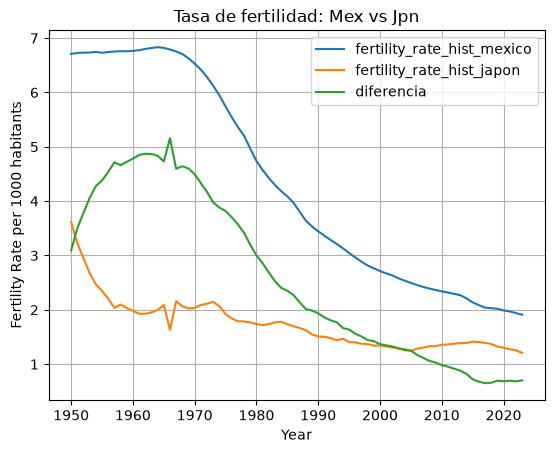

In [86]:
plt.Figure(figsize=(10,5))

comparison_mex_jpn.plot(
    x="year",
    y=["fertility_rate_hist_mexico", "fertility_rate_hist_japon", "diferencia"],
    kind="line"
)

plt.title('Tasa de fertilidad: Mex vs Jpn')
plt.xlabel('Year')
plt.ylabel('Fertility Rate per 1000 habitants')
plt.grid(True)
plt.legend()